In [1]:
# Telecom Customer Churn Analysis & Prediction

# 1. Project objective

# The project has two connected goals:

# Data Analysis

# Understand:

# Why are telecom customers leaving the company?

# Machine Learning

# Predict:

# Whether a customer is likely to churn based on their available customer information.

In [2]:
# Architecture :

""" 
   Dataset
      ↓
Data Understanding
      ↓
 Data Cleaning
      ↓
EDA / Visualization
      ↓
Feature Selection
      ↓
Preprocessing
      ↓
Logistic Regression
      ↓
Random Forest
      ↓
Model Evaluation & Comparison
      ↓
Business Insights """

' \n   Dataset\n      ↓\nData Understanding\n      ↓\n Data Cleaning\n      ↓\nEDA / Visualization\n      ↓\nFeature Selection\n      ↓\nPreprocessing\n      ↓\nLogistic Regression\n      ↓\nRandom Forest\n      ↓\nModel Evaluation & Comparison\n      ↓\nBusiness Insights '

In [6]:
#Import libraries:

# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

In [7]:
# Load the dataset

df = pd.read_csv("telco_customer_churn.csv")

In [8]:
df.head(15) # Check the first 15 records

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices
5,4190-MFLUW,1,United States,California,Los Angeles,90020,"34.066367, -118.309868",34.066367,-118.309868,Female,...,Month-to-month,No,Credit card (automatic),55.20,528.35,Yes,1,78,5925,Competitor offered higher download speeds
6,8779-QRDMV,1,United States,California,Los Angeles,90022,"34.02381, -118.156582",34.023810,-118.156582,Male,...,Month-to-month,Yes,Electronic check,39.65,39.65,Yes,1,100,5433,Competitor offered more data
7,1066-JKSGK,1,United States,California,Los Angeles,90024,"34.066303, -118.435479",34.066303,-118.435479,Male,...,Month-to-month,No,Mailed check,20.15,20.15,Yes,1,92,4832,Competitor made better offer
8,6467-CHFZW,1,United States,California,Los Angeles,90028,"34.099869, -118.326843",34.099869,-118.326843,Male,...,Month-to-month,Yes,Electronic check,99.35,4749.15,Yes,1,77,5789,Competitor had better devices
9,8665-UTDHZ,1,United States,California,Los Angeles,90029,"34.089953, -118.294824",34.089953,-118.294824,Male,...,Month-to-month,No,Electronic check,30.20,30.2,Yes,1,97,2915,Competitor had better devices


In [9]:
df.tail(10) # Check the last 10 records.

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
7033,0871-OPBXW,1,United States,California,Twentynine Palms,92277,"34.17211, -115.769773",34.172110,-115.769773,Female,...,Month-to-month,Yes,Mailed check,20.05,39.25,No,0,80,5191,NaN
7034,3605-JISKB,1,United States,California,Twentynine Palms,92278,"34.457829, -116.139589",34.457829,-116.139589,Male,...,One year,No,Credit card (automatic),60.00,3316.1,No,0,71,4212,NaN
7035,9767-FFLEM,1,United States,California,Westmorland,92281,"33.03679, -115.60503",33.036790,-115.605030,Male,...,Month-to-month,Yes,Credit card (automatic),69.50,2625.25,No,0,35,4591,NaN
7036,8456-QDAVC,1,United States,California,Winterhaven,92283,"32.852947, -114.850784",32.852947,-114.850784,Male,...,Month-to-month,Yes,Bank transfer (automatic),78.70,1495.1,No,0,20,2464,NaN
7037,7750-EYXWZ,1,United States,California,Yucca Valley,92284,"34.159534, -116.425984",34.159534,-116.425984,Female,...,One year,No,Electronic check,60.65,743.3,No,0,24,3740,NaN
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,...,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,...,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,...,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,...,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN
7042,3186-AJIEK,1,United States,California,Apple Valley,92308,"34.424926, -117.184503",34.424926,-117.184503,Male,...,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No,0,38,5097,NaN


In [10]:
df.shape # Check the dimensions

(7043, 33)

In [11]:
# Understand the dataset

df.columns # Columns name


Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [12]:
df.info()   

""" This tells us:

which columns are numeric
which are categorical
whether there are missing values
memory usage """

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

' This tells us:\n\nwhich columns are numeric\nwhich are categorical\nwhether there are missing values\nmemory usage '

In [16]:
# Statistical Summary

df.describe()


,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [17]:
# Check Missing values

df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [18]:
# Check duplicates

df.duplicated().sum()

np.int64(0)

In [19]:
df["CustomerID"].nunique() #Check CustomerID

7043

In [20]:
# Understand the target variable

df["Churn Label"].value_counts() # Our target

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [21]:
# gives approximately percentage of customers churned.

churn_rate = (df["Churn Label"] == "Yes").mean() * 100
print(f"Churn Rate: {churn_rate:.2f}%") 

Churn Rate: 26.54%


In [22]:
"""
Churn Label
Yes / No

This is our target variable.

We want our model to predict it.

Churn Value
0 / 1

This represents essentially the same outcome numerically.

We don't need it because we already have Churn Label.

Churn Score

This is already a churn-related score provided in the dataset.

We don't use it because we want our own ML model to predict churn.

Churn Reason

This tells us why customers who churned left.

We use it for:

Business Analysis

but not as an ML input.

CLTV

Customer Lifetime Value.

We keep it for:

Business Analysis

but don't use it in our initial prediction model.

"""

"\nChurn Label\nYes / No\n\nThis is our target variable.\n\nWe want our model to predict it.\n\nChurn Value\n0 / 1\n\nThis represents essentially the same outcome numerically.\n\nWe don't need it because we already have Churn Label.\n\nChurn Score\n\nThis is already a churn-related score provided in the dataset.\n\nWe don't use it because we want our own ML model to predict churn.\n\nChurn Reason\n\nThis tells us why customers who churned left.\n\nWe use it for:\n\nBusiness Analysis\n\nbut not as an ML input.\n\nCLTV\n\nCustomer Lifetime Value.\n\nWe keep it for:\n\nBusiness Analysis\n\nbut don't use it in our initial prediction model.\n\n"

In [23]:
# Clean Total Charges

df["Total Charges"].dtype


dtype('O')

In [24]:
#Convert it to numerical

df["Total Charges"] = pd.to_numeric(
    df["Total Charges"].astype(str).str.strip(),
    errors="coerce"
)

In [25]:
# Check missing values

df["Total Charges"].isnull().sum()

np.int64(11)

In [26]:
"""
 These customers have:

Tenure Months = 0

So for this dataset, we can reasonably replace those missing total charges with 0. """

df["Total Charges"] = df["Total Charges"].fillna(0)

In [27]:
df["Total Charges"].isnull().sum()

np.int64(0)

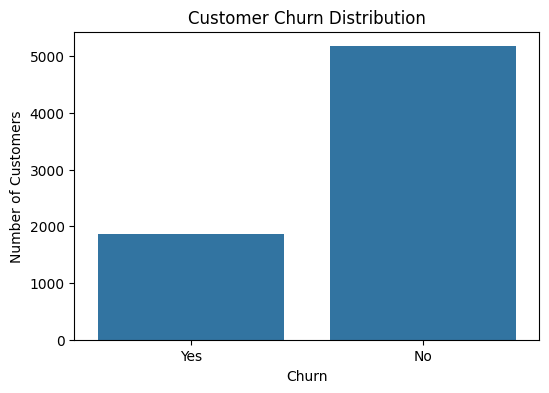

' \nWhat this tells us\n\nWe can see the difference between:\n\nCustomers who stayed\nvs\nCustomers who left \n                   '

In [28]:
# EDA — Churn distribution

# First Graph

plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Churn Label")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

""" 
What this tells us

We can see the difference between:

Customers who stayed
vs
Customers who left 
                   """

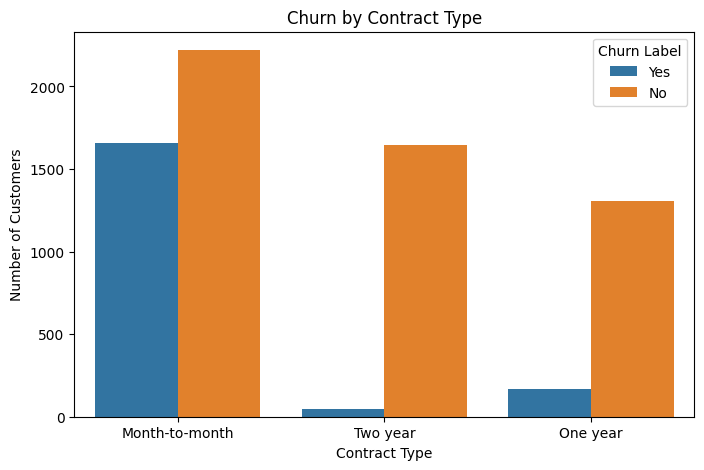

In [29]:
# Contract vs Churn

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn Label"
)

plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

In [30]:
# But counts aren't enough.

# We should calculate the actual churn rate:

contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn Label"],
    normalize="index"
) * 100

print(contract_churn)

Churn Label            No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


In [31]:
""" 
Business interpretation:

Customers on month-to-month contracts have a much higher observed churn rate than customers on longer contracts.

This is an important business insight. """

' \nBusiness interpretation:\n\nCustomers on month-to-month contracts have a much higher observed churn rate than customers on longer contracts.\n\nThis is an important business insight. '

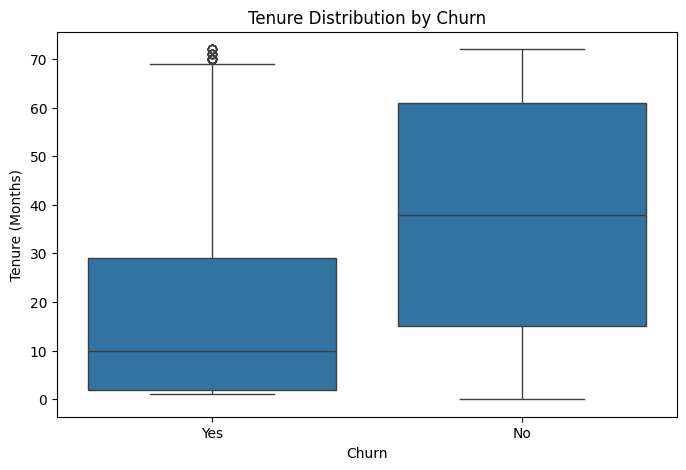

In [33]:
# Tenure vs Churn

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn Label",
    y="Tenure Months"
)

plt.title("Tenure Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

In [34]:
# Calculate averages:

df.groupby("Churn Label")["Tenure Months"].agg(
    ["mean", "median"]
)

,mean,median
Churn Label,,
No,37.569965,38.0
Yes,17.979133,10.0


In [39]:
""" 
Business Interpretation:

Churned customers generally have much shorter tenure.

This suggests that customer retention during the early period is particularly important. """

' \nBusiness Interpretation:\n\nChurned customers generally have much shorter tenure.\n\nThis suggests that customer retention during the early period is particularly important. '

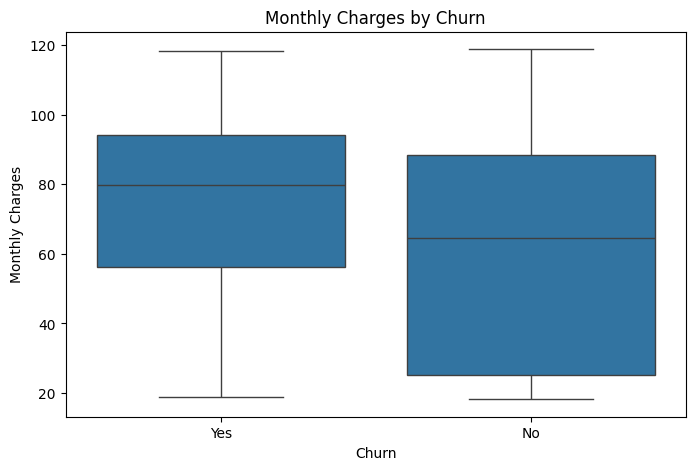

In [36]:
# Monthly Charges VS Churn

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn Label",
    y="Monthly Charges"
)

plt.title("Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

In [37]:
# Calculate:

df.groupby("Churn Label")["Monthly Charges"].agg(
    ["mean", "median"]
)

,mean,median
Churn Label,,
No,61.265124,64.425
Yes,74.441332,79.650


In [38]:
"""
Business Interpretation:

Churned customers have higher average monthly charges in this dataset.

That doesn't prove that high charges cause churn, but it shows an association worth investigating."""

"\nBusiness Interpretation:\n\nChurned customers have higher average monthly charges in this dataset.\n\nThat doesn't prove that high charges cause churn, but it shows an association worth investigating."

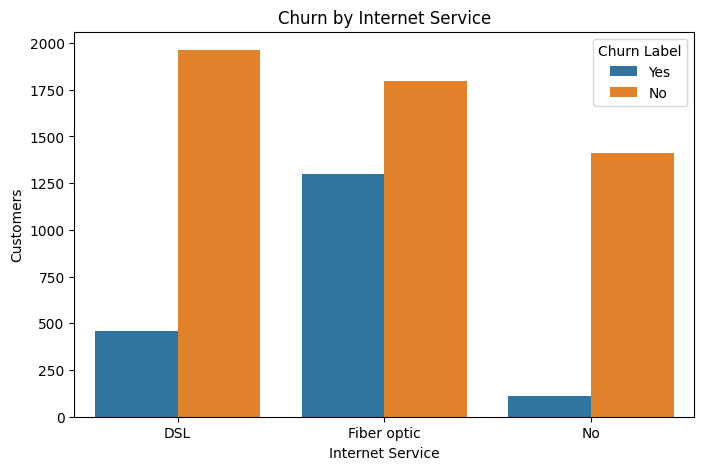

In [40]:
# Internet Service vs Churn

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Internet Service",
    hue="Churn Label"
)

plt.title("Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Customers")

plt.show()

In [41]:
# Calculate rates:

df.groupby("Internet Service")["Churn Label"].apply(
    lambda x: (x == "Yes").mean() * 100
)

Internet Service
DSL            18.959108
Fiber optic    41.892765
No              7.404980
Name: Churn Label, dtype: float64

In [42]:
# Again, this is an observed relationship, not proof that the service itself causes churn.

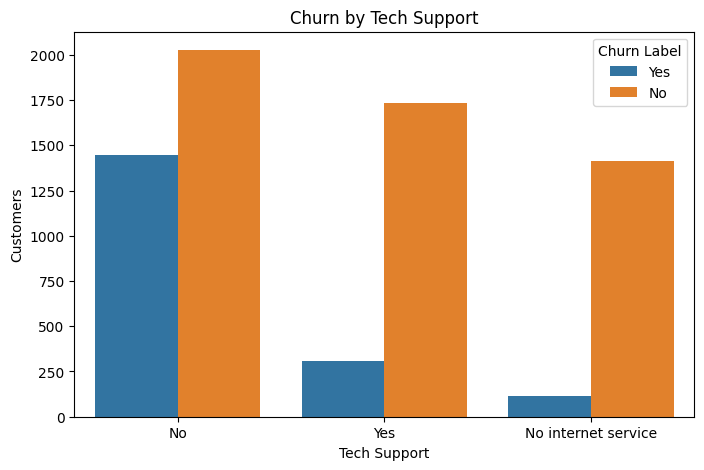

In [43]:
# Tech Support vs Churn

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Tech Support",
    hue="Churn Label"
)

plt.title("Churn by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Customers")

plt.show()

In [44]:
# Calculate rates :

df.groupby("Tech Support")["Churn Label"].apply(
    lambda x: (x == "Yes").mean() * 100
)

Tech Support
No                     41.635474
No internet service     7.404980
Yes                    15.166341
Name: Churn Label, dtype: float64

In [45]:
"""
Business Interpretation:

Customers without tech support have a substantially higher observed churn rate.

This could be an important retention area.
                                        """

'\nBusiness Interpretation:\n\nCustomers without tech support have a substantially higher observed churn rate.\n\nThis could be an important retention area.\n                                        '

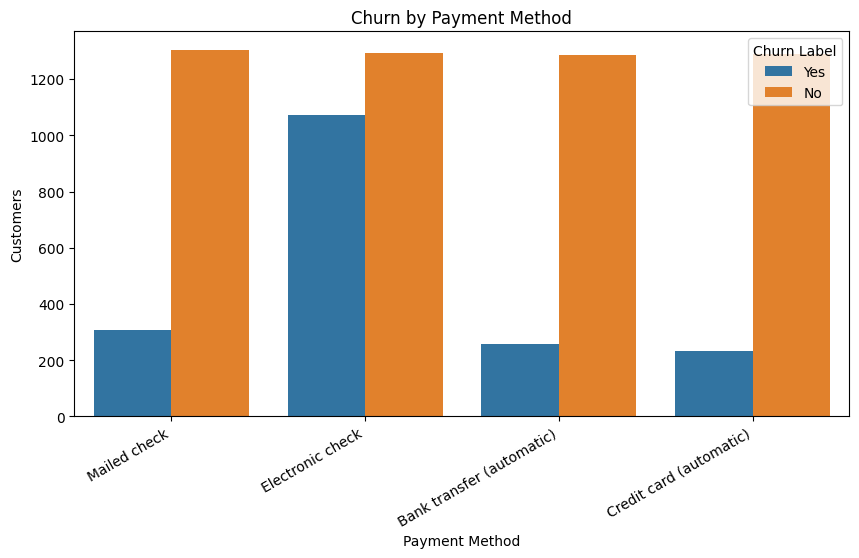

In [46]:
# Payment Method vs Churn

plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="Payment Method",
    hue="Churn Label"
)

plt.xticks(rotation=30, ha="right")

plt.title("Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Customers")

plt.show()

In [1]:
""" Business interpretation:

Customers who pay using Electronic Check are more likely to churn than customers using automatic bank transfer or automatic credit card payments."""

' Business interpretation:\n\nCustomers who pay using Electronic Check are more likely to churn than customers using automatic bank transfer or automatic credit card payments.'

In [47]:
# Churn rates:

df.groupby("Payment Method")["Churn Label"].apply(
    lambda x: (x == "Yes").mean() * 100
)

Payment Method
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Electronic check             45.285412
Mailed check                 19.106700
Name: Churn Label, dtype: float64

In [48]:
# Churn Reason

# Now we use the column specifically for business analysis.

churned = df[df["Churn Label"] == "Yes"]

churned["Churn Reason"].value_counts()

Churn Reason
Attitude of support person                   192
Competitor offered higher download speeds    189
Competitor offered more data                 162
Don't know                                   154
Competitor made better offer                 140
Attitude of service provider                 135
Competitor had better devices                130
Network reliability                          103
Product dissatisfaction                      102
Price too high                                98
Service dissatisfaction                       89
Lack of self-service on Website               88
Extra data charges                            57
Moved                                         53
Lack of affordable download/upload speed      44
Limited range of services                     44
Long distance charges                         44
Poor expertise of phone support               20
Poor expertise of online support              19
Deceased                                       6
Name: c

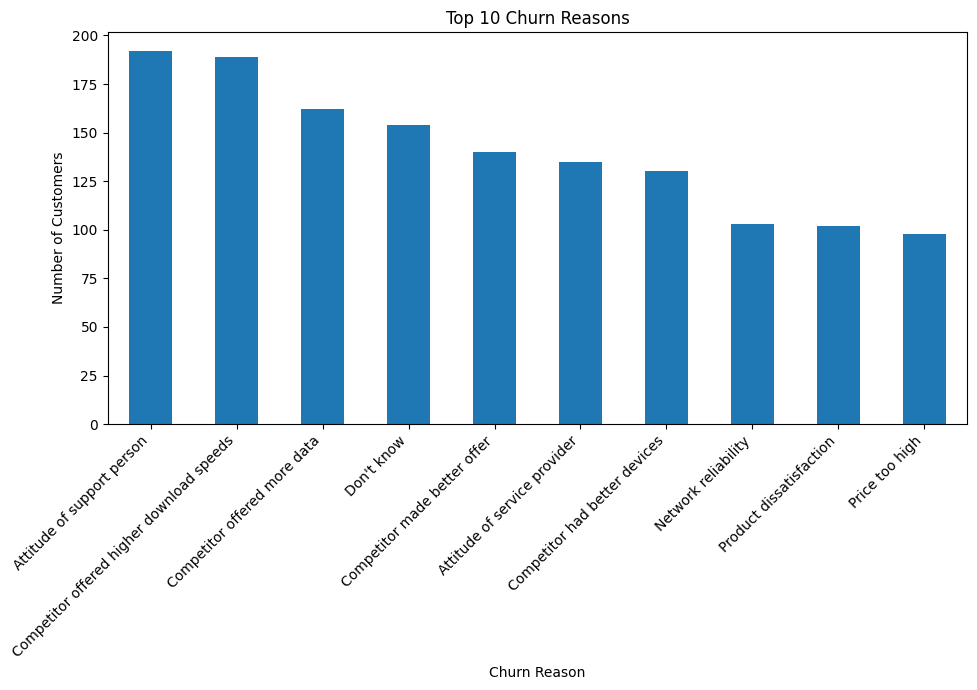

In [49]:
# Churn Reason Graph :

plt.figure(figsize=(10, 7))

churned["Churn Reason"].value_counts().head(10).plot(
    kind="bar"
)

plt.title("Top 10 Churn Reasons")
plt.xlabel("Churn Reason")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

In [50]:
"""
Important!!

We do not put Churn Reason into the ML model.

Why?

Because you're trying to predict churn before it happens. The reason is generally available when/after the customer has churned. """

"\nImportant!!\n\nWe do not put Churn Reason into the ML model.\n\nWhy?\n\nBecause you're trying to predict churn before it happens. The reason is generally available when/after the customer has churned. "

In [2]:
""" 
CLTV analysis

CLTV = Customer Lifetime Value.

We kept it for business analysis. """

' \nCLTV analysis\n\nCLTV = Customer Lifetime Value.\n\nWe kept it for business analysis. '

In [8]:
df.groupby("Churn Label")["CLTV"].agg(
    ["mean", "median"]
)

,mean,median
Churn Label,,
No,4490.921337,4620.0
Yes,4149.414660,4238.0


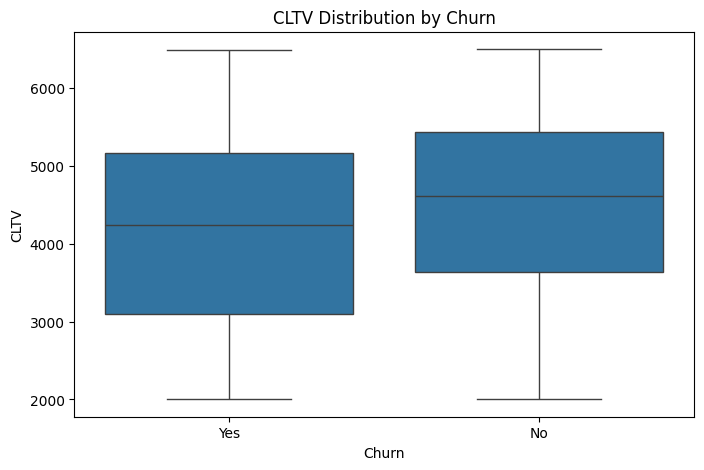

In [9]:
# Visualize CLTV:

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn Label",
    y="CLTV"
)

plt.title("CLTV Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("CLTV")

plt.show()

In [10]:
# CLTV helps the company identify which customers are financially valuable.
# This lets the business understand whether churned and retained customers differ in customer lifetime value.

In [11]:
""" 
Now prepare data for ML

This is where we separate:

X = input features
y = target  """

' \nNow prepare data for ML\n\nThis is where we separate:\n\nX = input features\ny = target  '

In [12]:
# Out Target:

y = df["Churn Label"].map({
    "No": 0,
    "Yes": 1
})

"""
So:

No  → 0
Yes → 1

"""

'\nSo:\n\nNo  → 0\nYes → 1\n\n'

In [13]:
"""
Which columns do we exclude?

We don't want:

CustomerID
Count
Country
State
City
Zip Code
Lat Long
Latitude
Longitude
Churn Value
Churn Score
CLTV
Churn Reason
Churn Label 

Why?

CustomerID → identifier

Count → essentially constant

Country/State → not useful for this simple model

City/Zip/Latitude/Longitude → geographic information, unnecessary for our basic model

Churn Value → duplicate outcome information

Churn Score → already contains churn-related prediction information

CLTV → business analysis only for this project

Churn Reason → post-churn information

Churn Label → target, not an input  """

"\nWhich columns do we exclude?\n\nWe don't want:\n\nCustomerID\nCount\nCountry\nState\nCity\nZip Code\nLat Long\nLatitude\nLongitude\nChurn Value\nChurn Score\nCLTV\nChurn Reason\nChurn Label \n\nWhy?\n\nCustomerID → identifier\n\nCount → essentially constant\n\nCountry/State → not useful for this simple model\n\nCity/Zip/Latitude/Longitude → geographic information, unnecessary for our basic model\n\nChurn Value → duplicate outcome information\n\nChurn Score → already contains churn-related prediction information\n\nCLTV → business analysis only for this project\n\nChurn Reason → post-churn information\n\nChurn Label → target, not an input  "

In [14]:
#Create X

drop_columns = [
    "CustomerID",
    "Count",
    "Country",
    "State",
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude",
    "Churn Label",
    "Churn Value",
    "Churn Score",
    "CLTV",
    "Churn Reason"
]

X = df.drop(columns=drop_columns)

In [15]:
X.shape

(7043, 19)

In [16]:
X.columns

Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months',
       'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges'],
      dtype='object')

In [17]:
"""
Train-test split:

We don't train and test on the same data.

We divide:

80% → Training
20% → Testing """

"\nTrain-test split:\n\nWe don't train and test on the same data.\n\nWe divide:\n\n80% → Training\n20% → Testing "

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [19]:
"""
Why random_state=42?

It makes our split reproducible.

Why stratify=y?

Our dataset has:

No  → 5174
Yes → 1869

The classes aren't equal.

stratify=y helps maintain a similar churn/non-churn proportion in training and testing. """

"\nWhy random_state=42?\n\nIt makes our split reproducible.\n\nWhy stratify=y?\n\nOur dataset has:\n\nNo  → 5174\nYes → 1869\n\nThe classes aren't equal.\n\nstratify=y helps maintain a similar churn/non-churn proportion in training and testing. "

In [20]:
# Identify numerical and categorical features

numeric_features = X.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X.select_dtypes(
    exclude=np.number
).columns.tolist()

In [21]:
"""
Numerical:

Tenure Months
Monthly Charges
Total Charges

Categorical:

Gender
Senior Citizen
Partner
Dependents
...
Contract
Payment Method """

'\nNumerical:\n\nTenure Months\nMonthly Charges\nTotal Charges\n\nCategorical:\n\nGender\nSenior Citizen\nPartner\nDependents\n...\nContract\nPayment Method '

In [22]:
"""
Why encoding is required

Machine learning models cannot directly understand:

Male
Female

Yes
No

Month-to-month
One year
Two year

So categorical values need to be converted into numerical representation.

We'll use:

OneHotEncoder

Example:

Contract

Month-to-month
One year
Two year

becomes something similar to:

Contract_Month-to-month
Contract_One year
Contract_Two year

with 0/1 values. """

"\nWhy encoding is required\n\nMachine learning models cannot directly understand:\n\nMale\nFemale\n\nYes\nNo\n\nMonth-to-month\nOne year\nTwo year\n\nSo categorical values need to be converted into numerical representation.\n\nWe'll use:\n\nOneHotEncoder\n\nExample:\n\nContract\n\nMonth-to-month\nOne year\nTwo year\n\nbecomes something similar to:\n\nContract_Month-to-month\nContract_One year\nContract_Two year\n\nwith 0/1 values. "

In [23]:
"""
Why scaling?

Numerical features have different ranges.

For example:

Tenure Months → 0–72

Monthly Charges → roughly 18–119

Total Charges → 0–9000+

Logistic Regression benefits from standardized numerical features.

We'll use:

StandardScaler()

Random Forest itself does not require scaling, but because we're building a shared preprocessing pipeline, scaling is harmless and keeps the workflow consistent."""

"\nWhy scaling?\n\nNumerical features have different ranges.\n\nFor example:\n\nTenure Months → 0–72\n\nMonthly Charges → roughly 18–119\n\nTotal Charges → 0–9000+\n\nLogistic Regression benefits from standardized numerical features.\n\nWe'll use:\n\nStandardScaler()\n\nRandom Forest itself does not require scaling, but because we're building a shared preprocessing pipeline, scaling is harmless and keeps the workflow consistent."

In [25]:
# Build preprocessing pipeline

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Then combine them:

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])



In [26]:
""" 
Why use a pipeline?

It ensures the same preprocessing is applied consistently during:

Training
Testing
Prediction """

' \nWhy use a pipeline?\n\nIt ensures the same preprocessing is applied consistently during:\n\nTraining\nTesting\nPrediction '

In [27]:
# Logistic Regression

# Create the model:

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

# Train:

logistic_model.fit(X_train, y_train)

# Predict:

y_pred_lr = logistic_model.predict(X_test)

# Get probabilities:

y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

In [28]:
"""
What Logistic Regression is doing

Very simply:

Customer information
        ↓
Calculate relationship between features
        ↓
Calculate probability of churn
        ↓
Probability
        ↓
Classification

For example:

Churn probability = 0.82

The default threshold is approximately:

0.5

so the model would classify it as:

Churn = Yes

It is a good baseline model because it is relatively simple and interpretable. """

'\nWhat Logistic Regression is doing\n\nVery simply:\n\nCustomer information\n        ↓\nCalculate relationship between features\n        ↓\nCalculate probability of churn\n        ↓\nProbability\n        ↓\nClassification\n\nFor example:\n\nChurn probability = 0.82\n\nThe default threshold is approximately:\n\n0.5\n\nso the model would classify it as:\n\nChurn = Yes\n\nIt is a good baseline model because it is relatively simple and interpretable. '

In [29]:
# Evaluate Logistic Regression

print("Accuracy:",
      accuracy_score(y_test, y_pred_lr))

print("Precision:",
      precision_score(y_test, y_pred_lr))

print("Recall:",
      recall_score(y_test, y_pred_lr))

print("F1 Score:",
      f1_score(y_test, y_pred_lr))

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob_lr))

Accuracy: 0.801277501774308
Precision: 0.6407185628742516
Recall: 0.5721925133689839
F1 Score: 0.6045197740112994
ROC-AUC: 0.8474850809889173


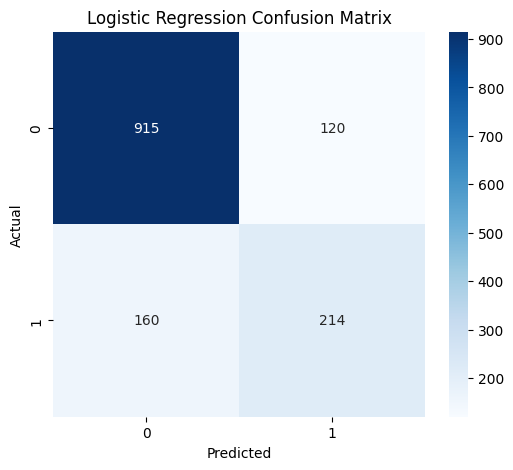

In [30]:
# Confusion Matrix — Logistic Regression

cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [31]:
"""
Your matrix was:

                Predicted
                No     Yes

Actual No       915    120
Actual Yes      160    214

Meaning:

915

Actual non-churn → predicted non-churn.

120

Actual non-churn → predicted churn.

160

Actual churn → predicted non-churn.

214

Actual churn → predicted churn. """

'\nYour matrix was:\n\n                Predicted\n                No     Yes\n\nActual No       915    120\nActual Yes      160    214\n\nMeaning:\n\n915\n\nActual non-churn → predicted non-churn.\n\n120\n\nActual non-churn → predicted churn.\n\n160\n\nActual churn → predicted non-churn.\n\n214\n\nActual churn → predicted churn. '

In [32]:
# Random Forest

# Now our second model.

random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

# Train:

random_forest_model.fit(X_train, y_train)

# Predict:

y_pred_rf = random_forest_model.predict(X_test)

# Probability:

y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

In [33]:
"""
What is Random Forest?

Random Forest consists of many decision trees.

Simple idea:

Customer
   ↓
Tree 1 → prediction
Tree 2 → prediction
Tree 3 → prediction
Tree 4 → prediction
...
Tree 300 → prediction
   ↓
Combine predictions
   ↓
Final prediction

Instead of relying on one decision tree, Random Forest combines many trees.

It can capture more complicated/nonlinear relationships between features. """

'\nWhat is Random Forest?\n\nRandom Forest consists of many decision trees.\n\nSimple idea:\n\nCustomer\n   ↓\nTree 1 → prediction\nTree 2 → prediction\nTree 3 → prediction\nTree 4 → prediction\n...\nTree 300 → prediction\n   ↓\nCombine predictions\n   ↓\nFinal prediction\n\nInstead of relying on one decision tree, Random Forest combines many trees.\n\nIt can capture more complicated/nonlinear relationships between features. '

In [34]:
#Evaluate Random Forest

print("Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print("Precision:",
      precision_score(y_test, y_pred_rf))

print("Recall:",
      recall_score(y_test, y_pred_rf))

print("F1 Score:",
      f1_score(y_test, y_pred_rf))

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob_rf))

Accuracy: 0.7934705464868701
Precision: 0.6387959866220736
Recall: 0.5106951871657754
F1 Score: 0.5676077265973254
ROC-AUC: 0.8327520731612803


In [35]:
#Compare both models

#Create a table:

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.801278,0.640719,0.572193,0.604520,0.847485
1,Random Forest,0.793471,0.638796,0.510695,0.567608,0.832752


In [37]:
#Random Forest feature importance

#This is optional but very useful for your project.

#Because we're using a pipeline, we first obtain the transformed feature names:

feature_names = (
    random_forest_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

In [38]:
# get importances:
importances = (
    random_forest_model
    .named_steps["model"]
    .feature_importances_
)

In [39]:
#Create a DataFrame:

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

In [40]:
# View top features:

feature_importance.head(15)

,Feature,Importance
0,numeric__Tenure Months,0.096729
1,numeric__Monthly Charges,0.081076
36,categorical__Contract_Month-to-month,0.034315
43,categorical__Payment Method_Electronic check,0.022939
27,categorical__Tech Support_No,0.020158
18,categorical__Online Security_No,0.019526
8,categorical__Dependents_No,0.018597
16,categorical__Internet Service_Fiber optic,0.018064
9,categorical__Dependents_Yes,0.017162
38,categorical__Contract_Two year,0.016482


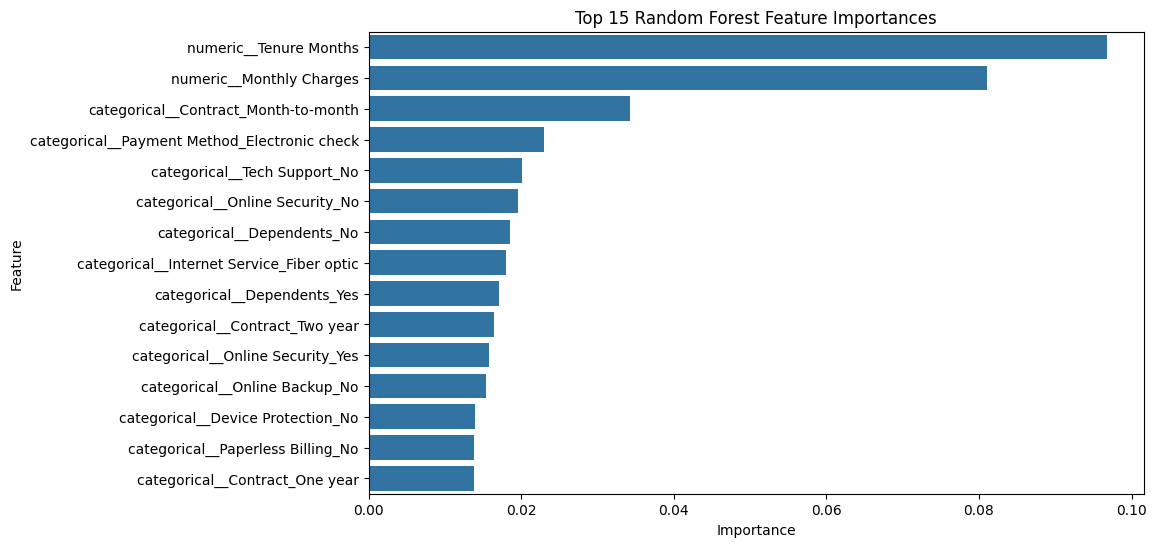

In [41]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Random Forest Feature Importances")

plt.show()

In [42]:
"""
What this means

Feature importance tells us which features the Random Forest used more strongly when creating its predictions.

It doesn't automatically mean that a feature causes churn.

That's an important distinction for interviews. """

"\nWhat this means\n\nFeature importance tells us which features the Random Forest used more strongly when creating its predictions.\n\nIt doesn't automatically mean that a feature causes churn.\n\nThat's an important distinction for interviews. "

In [43]:
# Business Insights:
# I analyzed customer behavior and built models to identify customers at risk of churn.

In [44]:
# Final Project Architecture :
"""
                 TELECOM CUSTOMER CHURN
                          │
                          ▼
                    CSV DATASET
                          │
                          ▼
                  DATA UNDERSTANDING
                          │
                          ▼
                    DATA CLEANING
                          │
                          ▼
                       EDA
              ┌───────────┴───────────┐
              │                       │
        Visualizations          Business Patterns
              │                       │
              └───────────┬───────────┘
                          ▼
                   ML PREPROCESSING
                          │
              ┌───────────┴───────────┐
              ▼                       ▼
       Logistic Regression      Random Forest
              │                       │
              └───────────┬───────────┘
                          ▼
                  MODEL EVALUATION
                          │
                          ▼
                 MODEL COMPARISON
                          │
                          ▼
                  BUSINESS INSIGHTS """

'\n                 TELECOM CUSTOMER CHURN\n                          │\n                          ▼\n                    CSV DATASET\n                          │\n                          ▼\n                  DATA UNDERSTANDING\n                          │\n                          ▼\n                    DATA CLEANING\n                          │\n                          ▼\n                       EDA\n              ┌───────────┴───────────┐\n              │                       │\n        Visualizations          Business Patterns\n              │                       │\n              └───────────┬───────────┘\n                          ▼\n                   ML PREPROCESSING\n                          │\n              ┌───────────┴───────────┐\n              ▼                       ▼\n       Logistic Regression      Random Forest\n              │                       │\n              └───────────┬───────────┘\n                          ▼\n                  MODEL EVALUATION\n    

In [45]:
"""
01. Import Libraries

02. Load Dataset

03. Understand Dataset
    - head()
    - shape
    - columns
    - info()
    - describe()

04. Data Quality Check
    - missing values
    - duplicates
    - data types
    - unique values

05. Data Cleaning
    - Total Charges
    - unnecessary columns

06. Exploratory Data Analysis
    - Churn Distribution
    - Contract vs Churn
    - Tenure vs Churn
    - Monthly Charges vs Churn
    - Internet Service vs Churn
    - Tech Support vs Churn
    - Payment Method vs Churn
    - Churn Reason

07. CLTV Business Analysis

08. Feature Selection

09. Train-Test Split

10. Preprocessing
    - Encoding
    - Scaling
    - Imputation

11. Logistic Regression

12. Logistic Regression Evaluation

13. Random Forest

14. Random Forest Evaluation

15. Model Comparison

16. Feature Importance

17. Business Insights

18. Conclusion """

'\n01. Import Libraries\n\n02. Load Dataset\n\n03. Understand Dataset\n    - head()\n    - shape\n    - columns\n    - info()\n    - describe()\n\n04. Data Quality Check\n    - missing values\n    - duplicates\n    - data types\n    - unique values\n\n05. Data Cleaning\n    - Total Charges\n    - unnecessary columns\n\n06. Exploratory Data Analysis\n    - Churn Distribution\n    - Contract vs Churn\n    - Tenure vs Churn\n    - Monthly Charges vs Churn\n    - Internet Service vs Churn\n    - Tech Support vs Churn\n    - Payment Method vs Churn\n    - Churn Reason\n\n07. CLTV Business Analysis\n\n08. Feature Selection\n\n09. Train-Test Split\n\n10. Preprocessing\n    - Encoding\n    - Scaling\n    - Imputation\n\n11. Logistic Regression\n\n12. Logistic Regression Evaluation\n\n13. Random Forest\n\n14. Random Forest Evaluation\n\n15. Model Comparison\n\n16. Feature Importance\n\n17. Business Insights\n\n18. Conclusion '

In [46]:
"""
Understand the logic:

What is the problem?
        ↓
What does the data contain?
        ↓
Can I trust/clean the data?
        ↓
What patterns exist?
        ↓
Which information should ML use?
        ↓
How do I convert it into ML-ready data?
        ↓
Can Logistic Regression predict churn?
        ↓
Can Random Forest predict churn?
        ↓
How well do they perform?
        ↓
What does the result mean for the business? """

'\nUnderstand the logic:\n\nWhat is the problem?\n        ↓\nWhat does the data contain?\n        ↓\nCan I trust/clean the data?\n        ↓\nWhat patterns exist?\n        ↓\nWhich information should ML use?\n        ↓\nHow do I convert it into ML-ready data?\n        ↓\nCan Logistic Regression predict churn?\n        ↓\nCan Random Forest predict churn?\n        ↓\nHow well do they perform?\n        ↓\nWhat does the result mean for the business? '

In [1]:
"""
Recommended project flow:

Dataset
   ↓
Data Cleaning
   ↓
EDA and Business Calculations
   ↓
Churn Prediction Models
   ↓
Model Comparison
   ↓
Business Analysis Report Generator
   ↓
Final Business Recommendations """

'\nRecommended project flow:\n\nDataset\n   ↓\nData Cleaning\n   ↓\nEDA and Business Calculations\n   ↓\nChurn Prediction Models\n   ↓\nModel Comparison\n   ↓\nBusiness Analysis Report Generator\n   ↓\nFinal Business Recommendations '

In [3]:
"""
What the report should contain:

1. Executive summary

Automatically display:

Total customers

Total churned customers

Overall churn rate

Average monthly charges

Average CLTV

Best-performing prediction model

Main business risks """

'\nWhat the report should contain:\n\n1. Executive summary\n\nAutomatically display:\n\nTotal customers\n\nTotal churned customers\n\nOverall churn rate\n\nAverage monthly charges\n\nAverage CLTV\n\nBest-performing prediction model\n\nMain business risks '

In [4]:
"""
Example:

The dataset contains 7,043 customers, of which 1,869 customers churned.
The overall churn rate is approximately 26.54%.

Customers with month-to-month contracts, higher monthly charges,
and electronic-check payment methods show higher observed churn rates.

Logistic Regression performed better than Random Forest in this experiment.
The company should focus on contract conversion, payment-method improvement,
and targeted retention campaigns. """

'\nExample:\n\nThe dataset contains 7,043 customers, of which 1,869 customers churned.\nThe overall churn rate is approximately 26.54%.\n\nCustomers with month-to-month contracts, higher monthly charges,\nand electronic-check payment methods show higher observed churn rates.\n\nLogistic Regression performed better than Random Forest in this experiment.\nThe company should focus on contract conversion, payment-method improvement,\nand targeted retention campaigns. '

In [8]:
total_customers = len(df)

churned_customers = (df["Churn Label"] == "Yes").sum()

churn_rate = (churned_customers / total_customers) * 100

print("Total Customers:", total_customers)
print("Churned Customers:", churned_customers)
print("Churn Rate:", round(churn_rate, 2), "%")

Total Customers: 7043
Churned Customers: 1869
Churn Rate: 26.54 %


In [9]:
if churn_rate > 25:
    print(
        "Business Interpretation: The company has a relatively high "
        "customer retention concern and should investigate major churn drivers."
    )
else:
    print(
        "Business Interpretation: The observed churn rate is comparatively lower, "
        "but high-risk customer segments should still be monitored."
    )

Business Interpretation: The company has a relatively high customer retention concern and should investigate major churn drivers.


In [10]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn Label"],
    normalize="index"
) * 100

contract_churn

Churn Label,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [11]:
highest_contract = (
    df.groupby("Contract")["Churn Value"]
    .mean()
    .idxmax()
)

highest_contract_rate = (
    df.groupby("Contract")["Churn Value"]
    .mean()
    .max() * 100
)

print(
    f"Business Interpretation: {highest_contract} contract customers "
    f"have the highest observed churn rate of "
    f"{highest_contract_rate:.2f}%."
)

Business Interpretation: Month-to-month contract customers have the highest observed churn rate of 42.71%.


In [12]:
tenure_summary = df.groupby("Churn Label")["Tenure Months"].agg(
    ["mean", "median"]
)

tenure_summary

,mean,median
Churn Label,,
No,37.569965,38.0
Yes,17.979133,10.0


In [13]:
def generate_business_report(df, model_comparison=None):

    total_customers = len(df)

    churned_customers = (df["Churn Label"] == "Yes").sum()

    churn_rate = (churned_customers / total_customers) * 100

    avg_cltv_no = df[df["Churn Label"] == "No"]["CLTV"].mean()
    avg_cltv_yes = df[df["Churn Label"] == "Yes"]["CLTV"].mean()

    highest_contract = (
        df.groupby("Contract")["Churn Value"]
        .mean()
        .idxmax()
    )

    highest_contract_rate = (
        df.groupby("Contract")["Churn Value"]
        .mean()
        .max() * 100
    )

    highest_payment = (
        df.groupby("Payment Method")["Churn Value"]
        .mean()
        .idxmax()
    )

    highest_payment_rate = (
        df.groupby("Payment Method")["Churn Value"]
        .mean()
        .max() * 100
    )

    report = f"""
==================================================
TELECOM CUSTOMER CHURN BUSINESS ANALYSIS REPORT
==================================================

1. EXECUTIVE SUMMARY
--------------------
Total Customers: {total_customers}
Churned Customers: {churned_customers}
Overall Churn Rate: {churn_rate:.2f}%

2. CONTRACT ANALYSIS
--------------------
Highest Churn Contract Type: {highest_contract}
Observed Churn Rate: {highest_contract_rate:.2f}%

Business Interpretation:
Customers with this contract type show the highest observed churn.
The company should investigate contract flexibility, pricing,
and incentives for longer-term contracts.

3. PAYMENT METHOD ANALYSIS
--------------------------
Highest Churn Payment Method: {highest_payment}
Observed Churn Rate: {highest_payment_rate:.2f}%

Business Interpretation:
This payment method is associated with the highest observed churn.
The company should investigate payment friction and encourage
convenient automatic payment options.

4. CLTV ANALYSIS
---------------
Average CLTV of Non-Churned Customers: {avg_cltv_no:.2f}
Average CLTV of Churned Customers: {avg_cltv_yes:.2f}

Business Interpretation:
Customers who stayed had a different average estimated lifetime
value from customers who churned. CLTV can help prioritize
retention campaigns for financially valuable customers.

5. RECOMMENDATIONS
------------------
- Improve onboarding for new customers.
- Encourage longer-term contracts.
- Investigate payment-related customer problems.
- Review pricing for high monthly-charge customers.
- Prioritize high-CLTV customers with high churn probability.
- Use targeted retention campaigns instead of one offer for everyone.

==================================================
END OF REPORT
==================================================
"""

    print(report)

    return report

In [14]:
business_report = generate_business_report(df)


TELECOM CUSTOMER CHURN BUSINESS ANALYSIS REPORT

1. EXECUTIVE SUMMARY
--------------------
Total Customers: 7043
Churned Customers: 1869
Overall Churn Rate: 26.54%

2. CONTRACT ANALYSIS
--------------------
Highest Churn Contract Type: Month-to-month
Observed Churn Rate: 42.71%

Business Interpretation:
Customers with this contract type show the highest observed churn.
The company should investigate contract flexibility, pricing,
and incentives for longer-term contracts.

3. PAYMENT METHOD ANALYSIS
--------------------------
Highest Churn Payment Method: Electronic check
Observed Churn Rate: 45.29%

Business Interpretation:
This payment method is associated with the highest observed churn.
The company should investigate payment friction and encourage
convenient automatic payment options.

4. CLTV ANALYSIS
---------------
Average CLTV of Non-Churned Customers: 4490.92
Average CLTV of Churned Customers: 4149.41

Business Interpretation:
Customers who stayed had a different average estim

In [15]:
# Save the report as a text file:
with open("telecom_business_analysis_report.txt", "w", encoding="utf-8") as file:
    file.write(business_report)

print("Business report saved successfully.")

Business report saved successfully.


In [18]:
# ============================================================
# ESSENTIAL BUSINESS ANALYSIS REPORT
# Telecom Customer Churn Analysis & Prediction
# ============================================================

def generate_business_report(df):

    # --------------------------------------------------------
    # 1. OVERALL CHURN
    # --------------------------------------------------------

    total_customers = len(df)

    churned = (df["Churn Label"] == "Yes").sum()

    churn_rate = (churned / total_customers) * 100


    # --------------------------------------------------------
    # 2. CONTRACT ANALYSIS
    # --------------------------------------------------------

    contract_churn = (
        df.groupby("Contract")["Churn Value"]
        .mean()
        .mul(100)
        .sort_values(ascending=False)
    )

    highest_contract = contract_churn.index[0]
    highest_contract_rate = contract_churn.iloc[0]


    # --------------------------------------------------------
    # 3. TENURE ANALYSIS
    # --------------------------------------------------------

    tenure = df.groupby("Churn Label")["Tenure Months"].mean()

    churned_tenure = tenure["Yes"]
    retained_tenure = tenure["No"]


    # --------------------------------------------------------
    # 4. MONTHLY CHARGES
    # --------------------------------------------------------

    charges = df.groupby("Churn Label")["Monthly Charges"].mean()

    churned_charges = charges["Yes"]
    retained_charges = charges["No"]


    # --------------------------------------------------------
    # 5. INTERNET SERVICE ANALYSIS
    # --------------------------------------------------------

    internet_churn = (
        df.groupby("Internet Service")["Churn Value"]
        .mean()
        .mul(100)
        .sort_values(ascending=False)
    )

    highest_internet = internet_churn.index[0]
    highest_internet_rate = internet_churn.iloc[0]


    # --------------------------------------------------------
    # 6. PAYMENT METHOD
    # --------------------------------------------------------

    payment_churn = (
        df.groupby("Payment Method")["Churn Value"]
        .mean()
        .mul(100)
        .sort_values(ascending=False)
    )

    highest_payment = payment_churn.index[0]
    highest_payment_rate = payment_churn.iloc[0]


    # --------------------------------------------------------
    # 7. TECH SUPPORT ANALYSIS
    # --------------------------------------------------------

    tech_support_churn = (
        df.groupby("Tech Support")["Churn Value"]
        .mean()
        .mul(100)
        .sort_values(ascending=False)
    )

    highest_support = tech_support_churn.index[0]
    highest_support_rate = tech_support_churn.iloc[0]


    # --------------------------------------------------------
    # 8. CLTV ANALYSIS
    # --------------------------------------------------------

    cltv = df.groupby("Churn Label")["CLTV"].mean()

    churned_cltv = cltv["Yes"]
    retained_cltv = cltv["No"]


    # --------------------------------------------------------
    # 9. GENERATE REPORT
    # --------------------------------------------------------

    report = f"""
============================================================
       TELECOM CUSTOMER CHURN BUSINESS ANALYSIS
============================================================


1. OVERALL CHURN
----------------

Total Customers  : {total_customers:,}
Churned Customers: {churned:,}
Churn Rate       : {churn_rate:.2f}%

Business Interpretation:
The company has an observed churn rate of {churn_rate:.2f}%.
Customer retention should therefore be monitored, especially
among high-risk customer segments.


2. CONTRACT ANALYSIS
--------------------

Highest Churn Contract:
{highest_contract} ({highest_contract_rate:.2f}%)

Business Interpretation:
{highest_contract} customers have the highest observed churn
rate. The company can investigate suitable incentives,
pricing, and benefits for longer-term contracts.


3. TENURE ANALYSIS
------------------

Average Tenure - Retained Customers:
{retained_tenure:.2f} months

Average Tenure - Churned Customers:
{churned_tenure:.2f} months

Business Interpretation:
Churned customers have lower average tenure than retained
customers. This suggests that newer customers may require
stronger onboarding and early-stage engagement.


4. MONTHLY CHARGES
------------------

Average Monthly Charges - Retained:
{retained_charges:.2f}

Average Monthly Charges - Churned:
{churned_charges:.2f}

Business Interpretation:
Churned customers have higher average monthly charges.
The company should review pricing and perceived value for
customers with higher monthly charges.


5. INTERNET SERVICE ANALYSIS
----------------------------

Highest Churn Internet Service:
{highest_internet} ({highest_internet_rate:.2f}%)

Business Interpretation:
{highest_internet} customers show the highest observed churn
rate among internet-service groups. The company should
investigate service quality, pricing, network performance,
and customer-support issues within this segment.


6. PAYMENT METHOD
------------------

Highest Churn Payment Method:
{highest_payment} ({highest_payment_rate:.2f}%)

Business Interpretation:
Customers using {highest_payment} show the highest observed
churn rate among payment methods. The company should
investigate payment friction and encourage convenient
automatic payment options.


7. TECH SUPPORT ANALYSIS
------------------------

Highest Churn Tech Support Group:
{highest_support} ({highest_support_rate:.2f}%)

Business Interpretation:
Customers in the '{highest_support}' Tech Support group show
the highest observed churn rate. The company should
investigate customer-support quality and service issues
within this segment.


8. CLTV ANALYSIS
----------------

Average CLTV - Retained Customers:
{retained_cltv:.2f}

Average CLTV - Churned Customers:
{churned_cltv:.2f}

Business Interpretation:
Retained customers have a higher average CLTV than churned
customers in this dataset. CLTV can be combined with churn
probability to prioritize valuable customers for retention.


9. FINAL BUSINESS RECOMMENDATIONS
----------------------------------

• Improve onboarding for new customers.

• Investigate month-to-month contract customers.

• Review pricing and perceived value for customers with
  high monthly charges.

• Investigate service quality among high-churn internet
  service segments.

• Investigate payment friction and encourage convenient
  automatic payment methods.

• Improve customer-support quality and monitor support-related
  customer issues.

• Monitor high-risk customer segments.

• Use CLTV together with predicted churn probability to
  prioritize retention campaigns.


IMPORTANT NOTE
--------------

These findings show associations observed in the dataset.
They do not prove that any individual factor directly causes
customer churn.

CLTV was retained for business analysis and was not used as
an ML prediction feature.


============================================================
                    END OF REPORT
============================================================
"""

    return report

In [19]:
business_report = generate_business_report(df)

print(business_report)


       TELECOM CUSTOMER CHURN BUSINESS ANALYSIS


1. OVERALL CHURN
----------------

Total Customers  : 7,043
Churned Customers: 1,869
Churn Rate       : 26.54%

Business Interpretation:
The company has an observed churn rate of 26.54%.
Customer retention should therefore be monitored, especially
among high-risk customer segments.


2. CONTRACT ANALYSIS
--------------------

Highest Churn Contract:
Month-to-month (42.71%)

Business Interpretation:
Month-to-month customers have the highest observed churn
rate. The company can investigate suitable incentives,
pricing, and benefits for longer-term contracts.


3. TENURE ANALYSIS
------------------

Average Tenure - Retained Customers:
37.57 months

Average Tenure - Churned Customers:
17.98 months

Business Interpretation:
Churned customers have lower average tenure than retained
customers. This suggests that newer customers may require
stronger onboarding and early-stage engagement.


4. MONTHLY CHARGES
------------------

Average Monthl

In [20]:
with open(
    "telecom_business_analysis_report.txt",
    "w",
    encoding="utf-8"
) as file:
    file.write(business_report)

print("Business report generated successfully!")

Business report generated successfully!


In [21]:
"""
Overall Churn → Contract → Tenure → Monthly Charges → Internet Service → Payment Method → Tech Support → CLTV → Recommendations. """

'\nOverall Churn → Contract → Tenure → Monthly Charges → Internet Service → Payment Method → Tech Support → CLTV → Recommendations. '